### Generating human faces with Adversarial Networks
<img src="https://www.strangerdimensions.com/wp-content/uploads/2013/11/reception-robot.jpg" width=320>
This time we'll train a neural net to generate plausible human faces in all their subtlty: appearance, expression, accessories, etc. 'Cuz when us machines gonna take over the Earth, there won't be any more faces left. We want to preserve this data for future iterations. Yikes...

Based on https://github.com/Lasagne/Recipes/pull/94 .

In [ ]:
#!L
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
    # we are going to download 1.4 gb file, downloading will take some time
    download_from_yadisk(
        short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
        filename=FILENAME,
        target_dir=TARGET_DIR
    )

    # alternative way: 
    #from gfile import download_list
    #download_list(url=https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW,
    #               filename=FILENAME, target_dir=TARGET_DIR)

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
GB = 2**30
assert filesize > 1 * GB, "{filesize} is too small, something wrong with downloading"

In [ ]:
#!L:bash
unzip celeba.zip

In [1]:
#!L
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
plt.rcParams.update({'axes.titlesize': 'small'})

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

use_cuda = torch.cuda.is_available()

print("Torch version:", torch.__version__)
if use_cuda:
    print("Using GPU")
else:
    print("Not using GPU")

Torch version: 2.0.1+cu118
Using GPU


### Prepare Dataset

In [2]:
#!L
class CropCelebA64:
    
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

In [8]:
#!L

# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)

# train_dataset = torchvision.datasets.CelebA(
#     root='celeba',
#     split='train',
#     transform=torchvision.transforms.Compose([
#         CropCelebA64(),
#         torchvision.transforms.Resize(64),
#         torchvision.transforms.RandomHorizontalFlip(),
#         torchvision.transforms.ToTensor(),
        
#         torchvision.transforms.Grayscale()
#     ]),
# )
from tqdm import tqdm
from PIL import Image

import os

class CelebARAM(Dataset):
    def __init__(self, root, split, transform=None):
        self.dataset = torchvision.datasets.CelebA(root=root, split=split)
        self.transform = transform
        self.images = []
        self.labels = []
        for idx in tqdm(range(len(self.dataset))):
            img_path, label = self.dataset.filename[idx], self.dataset[idx][1]
            img = Image.open(os.path.join(self.dataset.root, self.dataset.base_folder, "img_align_celeba", img_path))
            img = np.array(img, dtype=np.uint8)
            self.images.append(img)
            self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),   
        torchvision.transforms.Grayscale()
    ])

In [9]:
train_dataset = CelebARAM('celeba', 'train', train_transform)
IMG_SHAPE = tuple(train_dataset[0][0].shape)
IMG_SHAPE

100%|██████████| 162770/162770 [05:42<00:00, 475.83it/s]


(1, 64, 64)

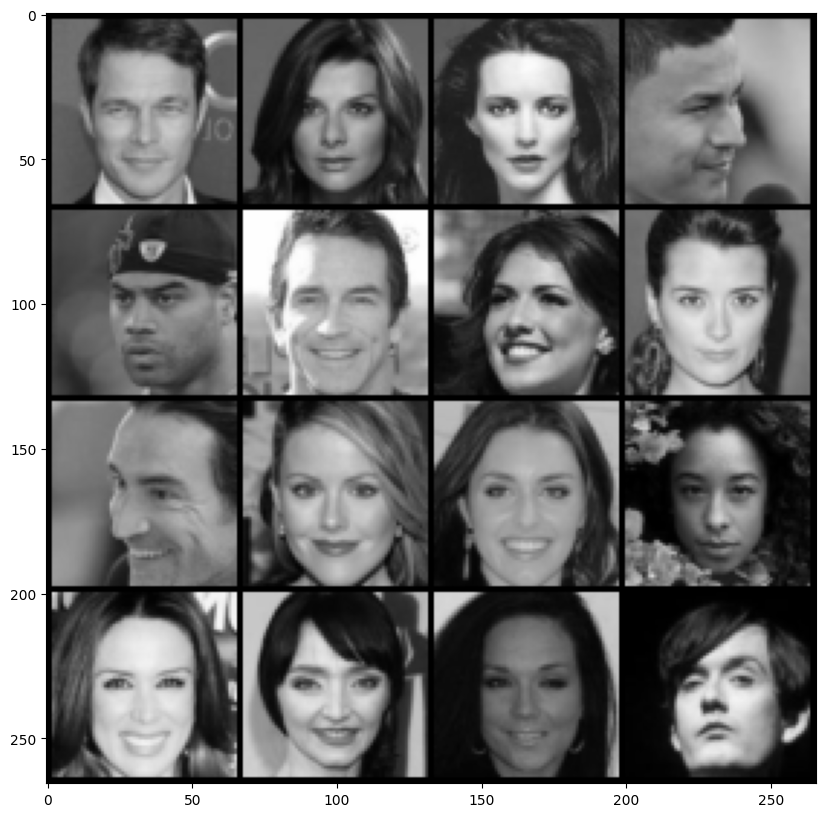

In [10]:
#!L
# print some images
samples = torch.stack([train_dataset[i][0] for i in range(32, 48)], dim=0)

plt.figure(figsize=(10, 10))
plt.imshow(make_grid(samples, nrow=4).permute(1, 2, 0))
plt.show()

# Generative adversarial nets 101

<img src="https://raw.githubusercontent.com/torch/torch.github.io/master/blog/_posts/images/model.png" width=320px height=240px>

Deep learning is simple, isn't it? 
* build some network that generates a face (small image)
* make up a __measure__ of __how good this face is__
* optimize with gradient descent :)


The only problem is: how can we engineers tell well-generated faces from bad? And i bet you we won't ask a designer for help. 

__If we can't tell good faces from bad, we delegate it to yet another neural network!__

That makes the two of them:
* __G__enerator - takes random noize for inspiration and tries to generate a face sample. 
  * Let's call him __G__(z), where z is a gaussian noize.
* __D__iscriminator - takes a face sample and tries to tell if it's great or fake. 
  * Predicts the probability of input image being a __real face__
  * Let's call him __D__(x), x being an image.
  * __D(x)__ is a predition for real image and __D(G(z))__ is prediction for the face made by generator.

Before we dive into training them, let's construct the two networks.

In [11]:
#!L
def sample_noise_batch(batch_size):
    noise = torch.randn(batch_size, CODE_SIZE)
    return noise.cuda() if use_cuda else noise.cpu()
    
class Reshape(nn.Module):
    def __init__(self, shape):
        nn.Module.__init__(self)
        self.shape = shape
    
    def forward(self,input):
        return input.view(self.shape)

In [68]:
#!L
CODE_SIZE = 128 # Size of z noise vector; feel free to change it

generator = nn.Sequential()

## YOUR CODE - create architecture for discriminator
## Note: please start simple. You can start with the layers below, but you are more than welcome to change it

generator.add_module('linear1', nn.Linear(CODE_SIZE, 512*8*8))
generator.add_module('act1', nn.ELU())
generator.add_module('reshape1', Reshape([-1, 512, 8, 8]))

generator.add_module('conv2', nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1))
generator.add_module('bn1', nn.BatchNorm2d(256))
generator.add_module('act2', nn.ELU())

generator.add_module('conv3', nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1))
generator.add_module('bn2', nn.BatchNorm2d(128))
generator.add_module('act3', nn.ELU())

generator.add_module('conv4', nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1))
generator.add_module('act_fin', nn.Sigmoid())

##TODO: define next layers

# generator.add_module('conv3', nn.Conv2d(64, 128, kernel_size=(3,3)))
# generator.add_module('act2', nn.ELU())
# generator.add_module('up1', nn.ConvTranspose2d(128, 64, kernel_size=(2,2), stride=2))
# generator.add_module('act3', nn.ELU())

# generator.add_module('conv4', nn.Conv2d(64, 128, kernel_size=(3,3), padding='same'))
# generator.add_module('act4', nn.ELU())
# generator.add_module('up2', nn.ConvTranspose2d(128, 64, kernel_size=(2,2), stride=2))
# generator.add_module('act5', nn.ELU())

# generator.add_module('conv5', nn.Conv2d(64, 128, kernel_size=(3,3), padding='same'))
# generator.add_module('act6', nn.ELU())
# generator.add_module('up3', nn.ConvTranspose2d(128, 128, kernel_size=(2,2), stride=2))
# generator.add_module('act7', nn.ELU())

# generator.add_module('conv6', nn.Conv2d(128, 64, kernel_size=(3,3), padding='same'))
# generator.add_module('act8', nn.ELU())
# generator.add_module('conv_fin', nn.Conv2d(64, 1, kernel_size=(2,2), padding='same'))
# generator.add_module('act_fin', nn.Sigmoid())


if use_cuda: generator.cuda()

In [63]:
#!L
generated_data = generator(sample_noise_batch(5))
assert tuple(generated_data.shape)[1:] == IMG_SHAPE, "generator must output an image of shape %s, but instead it produces %s"%(IMG_SHAPE, tuple(generated_data.shape)[1:])

### Discriminator
* Discriminator is your usual convolutional network with interlooping convolution and pooling layers
* The network does not include dropout/batchnorm to avoid learning complications.
* We also regularize the pre-output layer to prevent discriminator from being too certain.

In [25]:
#!L
def sample_data_batch(batch_size):
    idxs = np.random.choice(np.arange(len(train_dataset)), size=batch_size)
    batch = torch.stack([train_dataset[idx][0] for idx in idxs], dim=0)
    return batch.cuda() if use_cuda else batch.cpu()

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.shape[0], -1)

In [69]:
#!L
discriminator = nn.Sequential()

## YOUR CODE - create convolutional architecture for discriminator
## Note: please start simple. A few convolutions & poolings would do, inception/resnet is an overkill
discriminator.add_module("conv1", nn.Conv2d(1, 32, kernel_size=3, padding='same'))
discriminator.add_module("maxpool1", nn.MaxPool2d(kernel_size=2, stride=2))
discriminator.add_module("relu1", nn.ReLU())

discriminator.add_module("conv2", nn.Conv2d(32, 64, kernel_size=3, padding='same'))
discriminator.add_module("maxpool2", nn.MaxPool2d(kernel_size=2, stride=2))
discriminator.add_module("relu2", nn.ReLU())

discriminator.add_module("flatten", nn.Flatten())
discriminator.add_module("disc_logit", nn.Linear(16 * 16 * 64, 1))

if use_cuda: discriminator.cuda()

In [28]:
#!L
discriminator(sample_data_batch(4))

tensor([[-0.0018],
        [ 0.0695],
        [-0.0098],
        [ 0.0355]], device='cuda:0', grad_fn=<AddmmBackward0>)

# Training

We train the two networks concurrently:
* Train __discriminator__ to better distinguish real data from __current__ generator
* Train __generator__ to make discriminator think generator is real
* Since discriminator is a differentiable neural network, we train both with gradient descent.

Training is done iteratively until discriminator is no longer able to find the difference (or until you run out of patience).


### Tricks:
* Regularize discriminator output weights to prevent explosion
* Train generator with __adam__ to speed up training. Discriminator trains with SGD to avoid problems with momentum.
* More: https://github.com/soumith/ganhacks


In [31]:
#!L
def generator_loss(noise):
    """
    1. generate data given noise
    2. compute log P(real | gen noise)
    3. return generator loss (should be scalar)
    """
    generated_data = generator(noise)
    
    disc_on_generated_data = discriminator(generated_data)
    
    logp_gen_is_real = F.logsigmoid(disc_on_generated_data)
    
    loss = -1 * torch.mean(logp_gen_is_real)
    
    return loss

In [32]:
#!L
loss = generator_loss(sample_noise_batch(32))

print(loss)

assert len(loss.shape) == 0, "Loss must be scalar"

tensor(0.6906, device='cuda:0', grad_fn=<MulBackward0>)


In [33]:
#!L
def discriminator_loss(real_data, generated_data):
    """
    1. compute discriminator's output on real & generated data
    2. compute log-probabilities of real data being real, generated data being fake
    3. return discriminator loss (scalar)
    """
    disc_on_real_data = discriminator(real_data)
    disc_on_fake_data = discriminator(generated_data)
    
    logp_real_is_real = F.logsigmoid(disc_on_real_data)
    logp_gen_is_fake = F.logsigmoid(-disc_on_fake_data)
    
    loss = -1 * torch.mean(logp_real_is_real) - torch.mean(logp_gen_is_fake)
    return loss

In [34]:
#!L
loss = discriminator_loss(sample_data_batch(32), 
                   generator(sample_noise_batch(32)))

print(loss)

assert len(loss.shape) == 0, "Loss must be scalar"

tensor(1.3793, device='cuda:0', grad_fn=<SubBackward0>)


### Auxilary functions
Here we define a few helper functions that draw current data distributions and sample training batches.

In [35]:
#!L
def sample_images(nrow, ncol, sharp=False):
    images = generator(sample_noise_batch(batch_size=nrow*ncol))
    images = images.data.cpu().numpy().transpose([0, 2, 3, 1])
    if np.var(images)!=0:
        images = images.clip(0, 1)
    for i in range(nrow*ncol):
        plt.subplot(nrow,ncol,i+1)
        if sharp:
            plt.imshow(images[i], cmap="gray", interpolation="none")
        else:
            plt.imshow(images[i], cmap="gray")
    plt.show()

def sample_probas(batch_size):
    plt.title('Generated vs real data')
    D_real = torch.sigmoid(discriminator(sample_data_batch(batch_size)))
    generated_data_batch = generator(sample_noise_batch(batch_size))
    D_fake = torch.sigmoid(discriminator(generated_data_batch))
    
    plt.hist(D_real.data.cpu().numpy(),
             label='D(x)', alpha=0.5, range=[0,1])
    plt.hist(D_fake.data.cpu().numpy(),
             label='D(G(z))', alpha=0.5, range=[0,1])
    plt.legend(loc='best')
    plt.show()

### Training
Main loop.
We just train generator and discriminator in a loop and draw results once every N iterations.

In [70]:
#!L
# optimizers
disc_opt = torch.optim.SGD(discriminator.parameters(), lr=5e-3)
gen_opt = torch.optim.Adam(generator.parameters(), lr=1e-4)

24


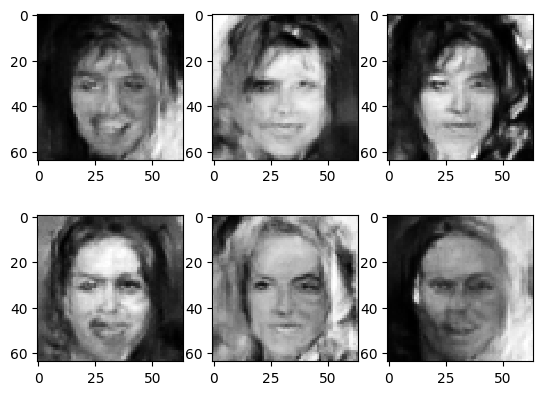

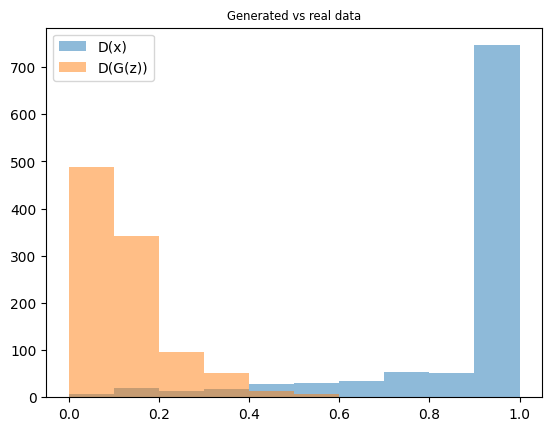

1627it [01:28, 18.33it/s]


In [71]:
#!L
from IPython import display
from tqdm.auto import tqdm

batch_size = 100
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

for epoch in range(25):
    for iteration, (batch, _) in tqdm(enumerate(loader)):

        # Train discriminator
        real_data = batch.cuda() if use_cuda else batch.cpu()
        fake_data = generator(sample_noise_batch(batch_size))
        loss = discriminator_loss(real_data, fake_data)
        disc_opt.zero_grad()
        loss.backward()
        disc_opt.step()

        # Train generator
        if iteration % 5 == 0:
            noise = sample_noise_batch(batch_size)
            loss = generator_loss(noise)
            gen_opt.zero_grad()
            loss.backward()
            gen_opt.step()

        if iteration % 100 == 0:
            display.clear_output(wait=True)
            print(epoch)

            sample_images(2,3,True)
            sample_probas(1000)
        

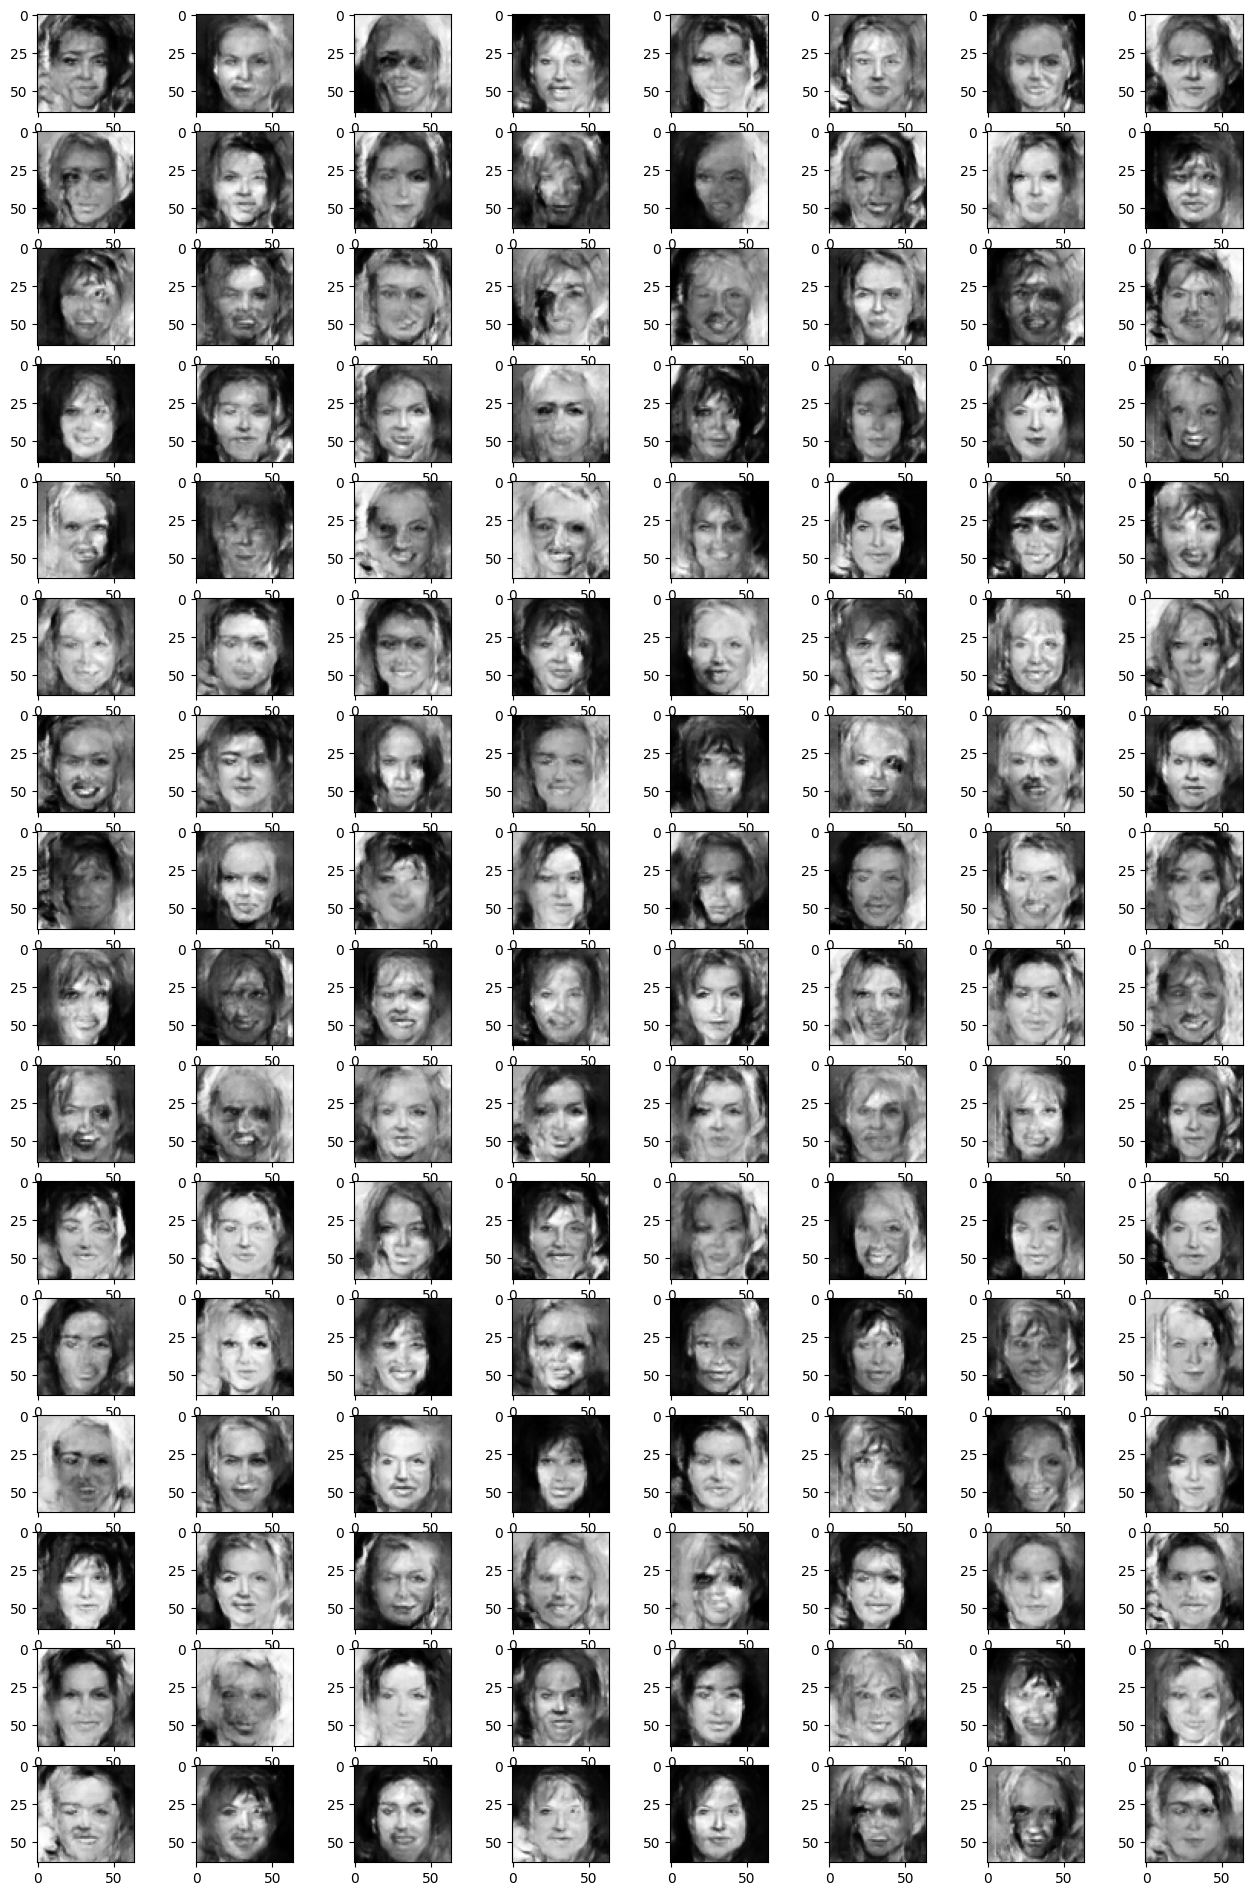

In [74]:
#!L
plt.figure(figsize=[16, 24])
sample_images(16, 8)

# Note: a no-nonsense neural network should be able to produce reasonably good images after 15k iterations
# By "reasonably good" we mean "resembling a car crash victim" or better